# <span style="color:#4CAF50">Recurrent Neural Network (RNN)</span>

---

## <span style="color:#2196F3">Why do we need RNN?</span>

Different types of data require different types of neural networks.

| Data Type                       | Neural Network                     |
| ------------------------------- | ---------------------------------- |
| Tabular Data                    | ANN (Artificial Neural Network)    |
| Grid-like Data (Images, Videos) | CNN (Convolutional Neural Network) |
| Sequential Data                 | RNN (Recurrent Neural Network)     |

### Sequential Data Examples

* Text Data
* Time Series Data
* Speech Data
* Stock Market Data
* Sensor Data

---

## <span style="color:#2196F3">What is RNN?</span>

* RNN (Recurrent Neural Network) is a type of neural network specially designed for **Sequential Data**.
* Unlike ANN, RNN remembers information from previous time steps and uses it while processing the current input.
* This memory helps the network understand the sequence and context of the data.

### Applications

* Sentiment Analysis
* Machine Translation
* Text Generation
* Autocomplete (Gmail)
* Question Answering Systems
* Image Caption Generation
* Music Generation
* Stock Price Prediction

---

# <span style="color:#FF5722">Problems with ANN for Sequential Data</span>

Suppose we have these sentences:

```text
I love NLP

Deep Learning is amazing

PyTorch is easy to learn
```

The sentence lengths are different.

### Problem 1: Zero Padding

To make input sizes equal, we often add zeros.

Example:

```text
I love NLP 0 0

Deep Learning is amazing 0

PyTorch is easy to learn
```

Disadvantages:

* Unnecessary computations
* Extra memory consumption

---

### Problem 2: Fixed Input Size

Suppose maximum sentence length during training is 10 words.

During inference, what if a sentence has 20 words?

ANN cannot naturally handle variable-length sequences.

---

### Problem 3: Loss of Sequence Information

ANN treats every feature independently.

Example:

```text
Dog bites man

Man bites dog
```

Both contain the same words.

But their meanings are completely different.

ANN cannot effectively capture this sequential relationship.

---

# <span style="color:#9C27B0">ANN vs RNN</span>

```text
ANN

Input  -------------> Hidden -------------> Output
```

No memory of previous inputs.

---

```text
RNN

        ┌──────────────┐
        │ Hidden State │
        └──────┬───────┘
               │
Input(t1) ---> Hidden(t1) ----┐
                              │
Input(t2) ---> Hidden(t2) <---┘
                              │
Input(t3) ---> Hidden(t3)
                              │
                              ▼
                           Output
```

RNN passes information from one time step to the next.

---

# <span style="color:#2196F3">Data Format for RNN</span>

Before feeding text into RNN:

### Step 1

Preprocess the text.

* Lowercasing
* Tokenization
* Lemmatization
* Stopword Removal

---

### Step 2

Convert text into numerical vectors using feature extraction techniques.

Examples:

* One Hot Encoding
* Word Embedding
* Word2Vec
* GloVe

---

### Step 3

RNN expects data in the form:

```text
[Time Steps, Number of Features]
```

### Example

Suppose we have:

* 3 Sentences
* Each sentence contains 3 words
* Each word is represented by a vector of size 5

Then:

```text
Time Steps = 3
Features = 5
```

Representation:

```text
[
  [x11 x12 x13 x14 x15],
  [x21 x22 x23 x24 x25],
  [x31 x32 x33 x34 x35]
]
```

Here,

* Time Steps = Words
* Features = Embedding Dimensions

---

# <span style="color:#2196F3">RNN Architecture</span>

The most important idea:

> The hidden state from the current time step becomes an input for the next time step.

```text
            h0

             │

             ▼

x1 ------> h1 ------> y1
            │
            ▼

x2 ------> h2 ------> y2
            │
            ▼

x3 ------> h3 ------> y3
            │
            ▼

x4 ------> h4 ------> y4
```

Where:

* x = Input
* h = Hidden State
* y = Output

The hidden state carries information from previous words.

This allows RNN to preserve sequence information.

---

# <span style="color:#2196F3">Forward Propagation</span>

RNN processes data one time step at a time.

For each time step:

```text
Current Hidden State
=
Previous Hidden State
+
Current Input
```

Mathematically:

```text
Ht = AF(Ht-1 × Wh + Xt × Wi + Bias)
```

Where:

* Ht = Current Hidden State
* Ht-1 = Previous Hidden State
* Xt = Current Input
* Wh = Hidden State Weight
* Wi = Input Weight
* AF = Activation Function

Final Output:

```text
Ŷ = AF(Hfinal × Wo + Bias)
```

---

# <span style="color:#2196F3">Backpropagation Through Time (BPTT)</span>

* RNN performs backpropagation across all time steps.
* Gradients flow from the final output back through every previous hidden state.
* This process is called **Backpropagation Through Time (BPTT).**

```text
Forward

x1 ---> x2 ---> x3 ---> x4

Backward

x1 <--- x2 <--- x3 <--- x4
```

---

# <span style="color:#F44336">Problems with RNN</span>

## 1. Long-Term Dependencies

Suppose a sentence is very long.

The network may forget information from earlier words.

Example:

```text
The movie that I watched last year with my friends was absolutely amazing.
```

The word **movie** may become difficult to remember after many time steps.

---

## 2. Vanishing Gradient Problem

During backpropagation,

many small numbers are multiplied repeatedly.

```text
0.5 × 0.5 × 0.5 × 0.5 × ...
```

Eventually:

```text
≈ 0
```

As a result:

* Early layers stop learning.
* Long-term memory is lost.

---

## 3. Exploding Gradient Problem

If large numbers are multiplied repeatedly:

```text
2 × 2 × 2 × 2 × ...
```

The gradients become extremely large.

Results:

* Unstable training
* Large weight updates
* Model divergence

---

# <span style="color:#4CAF50">Solutions for Vanishing Gradient</span>

1. Use better Activation Functions

* ReLU
* Leaky ReLU

2. Better Weight Initialization

3. Use Skip Connections / Skip RNNs

4. Replace RNN with LSTM or GRU

---

# <span style="color:#4CAF50">Solutions for Exploding Gradient</span>

1. Gradient Clipping

2. Controlled Learning Rate

3. Better Weight Initialization

4. Use LSTM / GRU

---

# <span style="color:#2196F3">Types of RNN</span>

---

## 1. Many-to-One

### Input

Sequence

### Output

Single Value

```text
Word1 --->

Word2 ---> Hidden ---> Output

Word3 --->
```

Applications:

* Sentiment Analysis
* Rating Prediction
* Spam Detection

---

## 2. One-to-Many

### Input

Single Input

### Output

Sequence

```text
Image ---> Hidden ---> Word1 ---> Word2 ---> Word3
```

Applications:

* Image Caption Generation
* Music Generation

---

## 3. Many-to-Many (Sequence to Sequence)

### Input

Sequence

### Output

Sequence

```text
English Sentence
        │
        ▼
      RNN
        │
        ▼
French Sentence
```

Applications:

* Machine Translation
* Text Summarization
* Chatbots

---

## 4. One-to-One

```text
Input ---> Output
```

This is actually a normal neural network and **not a typical RNN architecture.**

Example:

* Image Classification

---

# <span style="color:#9C27B0">Quick Summary</span>

### Why RNN?

* Handles Sequential Data
* Maintains Context
* Preserves Order of Inputs

### Major Applications

* NLP
* Time Series
* Translation
* Sentiment Analysis
* Text Generation

### Main Problems

* Long-Term Dependencies
* Vanishing Gradient
* Exploding Gradient

### Common Solutions

* Better Activation Functions
* Better Weight Initialization
* Gradient Clipping
* LSTM
* GRU

---

# <span style="background-color:#FFF3CD; color:#856404; padding:6px">

### Key Idea

**ANN processes inputs independently.**

**RNN processes inputs sequentially and remembers information from previous time steps using hidden states.**

</span>


# Basic RNN Building

## Full code with Forward + BPTT from scratch.

📉 Loss Before Update: 0.0797
📉 Loss After  Update: 0.0746


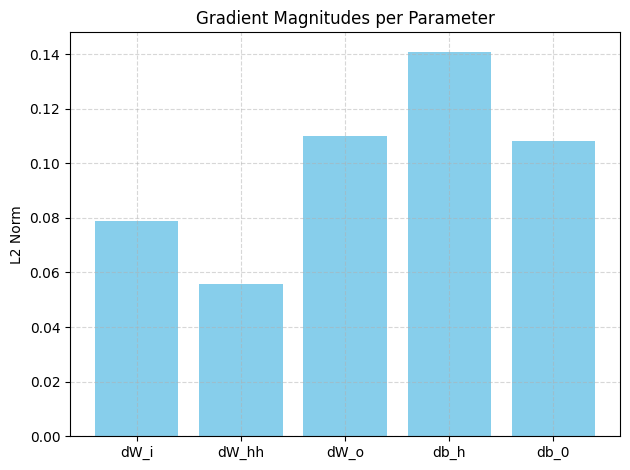

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- step - : input ------------
word_vectors = {
    "I": np.array([0.1, 0.2]),
    "love": np.array([0.5, 0.2]),
    "NLP": np.array([0.3, 0.7])
}

sentence = ["I", "love", "NLP"]
true_labels = np.array([0, 1])  # class 1 = positive

# ----- step 2 : RNN parameters
np.random.seed(93)

W_i = np.random.randn(2, 2)      # input weights
W_hh = np.random.randn(2, 2)     # hidden weights
W_o = np.random.randn(2, 2)      # output weights

b_h = np.zeros(2)
b_0 = np.zeros(2)

# ------- step 3: forward pass -----------
def softmax(x):
    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum()


h_0 = np.zeros(2)
h_list = [h_0]
x_list = []

# forward pass through time --> time steps
for word in sentence:
    x_t = word_vectors[word]
    x_list.append(x_t)

    h_prev = h_list[-1]

    h_t = np.tanh(
        np.dot(W_i, x_t) +
        np.dot(W_hh, h_prev) +
        b_h
    )

    h_list.append(h_t)

# final prediction
logits = np.dot(W_o, h_list[-1]) + b_0
y_pred = softmax(logits)

initial_loss = -np.log(
    y_pred[np.argmax(true_labels)]
)

# ---------- STEP 4: Backpropagation Through Time ----------

# Output layer gradient
d_logits = y_pred - true_labels

# Gradients for output weights
dW_o = np.outer(d_logits, h_list[-1])
db_0 = d_logits.copy()

dh_next = np.dot(W_o.T, d_logits)

# Initialize RNN gradients
dW_i = np.zeros_like(W_i)
dW_hh = np.zeros_like(W_hh)
db_h = np.zeros_like(b_h)

# BPTT
for t in reversed(range(len(sentence))):

    h_t = h_list[t + 1]
    h_prev = h_list[t]
    x_t = x_list[t]

    dz = (1 - h_t**2) * dh_next

    db_h += dz
    dW_i += np.outer(dz, x_t)
    dW_hh += np.outer(dz, h_prev)

    dh_next = np.dot(W_hh.T, dz)

# ---------- STEP 5: Update Weights ----------

learning_rate = 0.1

W_i -= learning_rate * dW_i
W_hh -= learning_rate * dW_hh
W_o -= learning_rate * dW_o

b_h -= learning_rate * db_h
b_0 -= learning_rate * db_0

# ---------- STEP 6: Forward Again After Update ----------

h_0 = np.zeros(2)
h_list = [h_0]
x_list = []

for word in sentence:

    x_t = word_vectors[word]
    x_list.append(x_t)

    h_prev = h_list[-1]

    h_t = np.tanh(
        np.dot(W_i, x_t) +
        np.dot(W_hh, h_prev) +
        b_h
    )

    h_list.append(h_t)

logits = np.dot(W_o, h_list[-1]) + b_0
y_pred = softmax(logits)

updated_loss = -np.log(
    y_pred[np.argmax(true_labels)]
)

# ---------- STEP 7: Print Comparison ----------

print("📉 Loss Before Update:", round(initial_loss, 4))
print("📉 Loss After  Update:", round(updated_loss, 4))

# ---------- STEP 8: Visualize Gradient Flow ----------

gradients = {
    "dW_i": np.linalg.norm(dW_i),
    "dW_hh": np.linalg.norm(dW_hh),
    "dW_o": np.linalg.norm(dW_o),
    "db_h": np.linalg.norm(db_h),
    "db_0": np.linalg.norm(db_0),
}

plt.bar(
    gradients.keys(),
    gradients.values(),
    color="skyblue"
)

plt.title("Gradient Magnitudes per Parameter")
plt.ylabel("L2 Norm")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


## NLP tasks

### 1. Sentiment Analysis

In [21]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

# ------------------- Data -------------------

sentences = [
    'i love it',
    'i hate it',
    'so good',
    'very bad',
    'awesome movie',
    'worst ever'
]

labels = [1, 0, 1, 0, 1, 0]

# ------------------- Build Vocabulary -------------------

vocab = {"<UNK>": 0}


def tokenize(text):
    text = text.lower()
    text = text.replace(".", "")
    return text.split()


def build_vocab(sentences):
    for text in sentences:
        tokens = tokenize(text)

        for token in tokens:
            if token not in vocab:
                vocab[token] = len(vocab)


def text_to_indices(text, vocab):

    indexed_text = []

    for token in tokenize(text):

        if token in vocab:
            indexed_text.append(vocab[token])

        else:
            indexed_text.append(vocab["<UNK>"])

    return indexed_text


build_vocab(sentences)

print(vocab)

# ------------------- Convert to Integer Sequences -------------------

X = []

for sentence in sentences:
    X.append(text_to_indices(sentence, vocab))

# ------------------- Padding -------------------

max_len = max(len(seq) for seq in X)

for i in range(len(X)):
    while len(X[i]) < max_len:
        X[i].append(0)

X = np.array(X)
y = np.array(labels)

print(X)

# ------------------- Convert to Tensor -------------------

X_tensor = torch.LongTensor(X)
y_tensor = torch.FloatTensor(y).view(-1, 1)

# ------------------- Build RNN Model -------------------

class RNNModel(nn.Module):

    def __init__(self, vocab_size):

        super().__init__()

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=8
        )

        self.rnn = nn.RNN(
            input_size=8,
            hidden_size=16,
            batch_first=True
        )

        self.fc = nn.Linear(16, 1)

    def forward(self, x):

        x = self.embedding(x)

        output, hidden = self.rnn(x)

        x = hidden.squeeze(0)

        x = self.fc(x)

        return x


model = RNNModel(len(vocab))

# ------------------- Loss and Optimizer -------------------

criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.01
)

# ------------------- Training -------------------

epochs = 100

for epoch in range(epochs):

    outputs = model(X_tensor)

    loss = criterion(
        outputs,
        y_tensor
    )

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch+1}, Loss: {loss.item():.4f}"
        )

# ------------------- Prediction -------------------

test_sentence = "really good"

test_seq = text_to_indices(
    test_sentence,
    vocab
)

while len(test_seq) < max_len:
    test_seq.append(0)

test_tensor = torch.LongTensor(
    [test_seq]
)

model.eval()

with torch.no_grad():

    prediction = torch.sigmoid(
        model(test_tensor)
    )

    print(
        "Probability:",
        prediction.item()
    )

    if prediction.item() >= 0.5:
        print("Prediction : Positive")
    else:
        print("Prediction : Negative")

{'<UNK>': 0, 'i': 1, 'love': 2, 'it': 3, 'hate': 4, 'so': 5, 'good': 6, 'very': 7, 'bad': 8, 'awesome': 9, 'movie': 10, 'worst': 11, 'ever': 12}
[[ 1  2  3]
 [ 1  4  3]
 [ 5  6  0]
 [ 7  8  0]
 [ 9 10  0]
 [11 12  0]]
Epoch 10, Loss: 0.4067
Epoch 20, Loss: 0.0873
Epoch 30, Loss: 0.0139
Epoch 40, Loss: 0.0046
Epoch 50, Loss: 0.0026
Epoch 60, Loss: 0.0019
Epoch 70, Loss: 0.0016
Epoch 80, Loss: 0.0014
Epoch 90, Loss: 0.0012
Epoch 100, Loss: 0.0011
Probability: 0.9944093823432922
Prediction : Positive


### 2. Machine Translation

In [22]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

# -------------------- Step 1 : Dummy Parallel Corpus --------------------

eng_sentences = [
    'hi there',
    'hello you',
    'thanks much'
]

fr_sentences = [
    'salut toi',
    'bonjour toi',
    'merci beaucoup'
]

# -------------------- Step 2 : Build Vocabulary --------------------

vocab_en = {"<PAD>": 0, "<UNK>": 1}
vocab_fr = {"<PAD>": 0, "<UNK>": 1}


def tokenize(text):
    return text.lower().split()


def build_vocab(sentences, vocab):

    for sentence in sentences:

        for token in tokenize(sentence):

            if token not in vocab:
                vocab[token] = len(vocab)


build_vocab(eng_sentences, vocab_en)
build_vocab(fr_sentences, vocab_fr)

print(vocab_en)
print(vocab_fr)

# -------------------- Step 3 : Convert Text to Indices --------------------

def text_to_indices(text, vocab):

    output = []

    for token in tokenize(text):

        if token in vocab:
            output.append(vocab[token])

        else:
            output.append(vocab["<UNK>"])

    return output


X = [text_to_indices(text, vocab_en)
     for text in eng_sentences]

y = [text_to_indices(text, vocab_fr)
     for text in fr_sentences]

# -------------------- Step 4 : Padding --------------------

max_len = max(
    max(len(seq) for seq in X),
    max(len(seq) for seq in y)
)

for seq in X:
    while len(seq) < max_len:
        seq.append(0)

for seq in y:
    while len(seq) < max_len:
        seq.append(0)

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

# -------------------- Step 5 : Tensor Conversion --------------------

X_tensor = torch.LongTensor(X)
y_tensor = torch.LongTensor(y)

# -------------------- Step 6 : Build RNN Model --------------------

class Seq2SeqRNN(nn.Module):

    def __init__(self,
                 input_vocab_size,
                 output_vocab_size):

        super().__init__()

        self.embedding = nn.Embedding(
            input_vocab_size,
            8
        )

        self.rnn = nn.RNN(
            input_size=8,
            hidden_size=16,
            batch_first=True
        )

        self.fc = nn.Linear(
            16,
            output_vocab_size
        )

    def forward(self, x):

        x = self.embedding(x)

        output, hidden = self.rnn(x)

        output = self.fc(output)

        return output


model = Seq2SeqRNN(
    len(vocab_en),
    len(vocab_fr)
)

# -------------------- Step 7 : Loss and Optimizer --------------------

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.01
)

# -------------------- Step 8 : Training --------------------

epochs = 300

for epoch in range(epochs):

    outputs = model(X_tensor)

    loss = criterion(
        outputs.reshape(-1, len(vocab_fr)),
        y_tensor.reshape(-1)
    )

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    if (epoch + 1) % 50 == 0:

        print(
            f"Epoch {epoch+1}, Loss: {loss.item():.4f}"
        )

# -------------------- Step 9 : Translation --------------------

test_sentence = "hello you"

test_seq = text_to_indices(
    test_sentence,
    vocab_en
)

while len(test_seq) < max_len:
    test_seq.append(0)

test_tensor = torch.LongTensor(
    [test_seq]
)

model.eval()

with torch.no_grad():

    prediction = model(test_tensor)

    prediction = torch.argmax(
        prediction,
        dim=2
    )

# -------------------- Step 10 : Decode --------------------

idx2word = {
    index: word
    for word, index
    in vocab_fr.items()
}

translation = []

for idx in prediction[0]:

    word = idx2word.get(
        idx.item(),
        ""
    )

    if word != "<PAD>":
        translation.append(word)

print(
    "Translation:",
    " ".join(translation)
)

{'<PAD>': 0, '<UNK>': 1, 'hi': 2, 'there': 3, 'hello': 4, 'you': 5, 'thanks': 6, 'much': 7}
{'<PAD>': 0, '<UNK>': 1, 'salut': 2, 'toi': 3, 'bonjour': 4, 'merci': 5, 'beaucoup': 6}
(3, 2)
(3, 2)
Epoch 50, Loss: 0.0167
Epoch 100, Loss: 0.0059
Epoch 150, Loss: 0.0034
Epoch 200, Loss: 0.0023
Epoch 250, Loss: 0.0016
Epoch 300, Loss: 0.0012
Translation: bonjour toi
